In [1]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Data Overview

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from IPython.display import Image

sns.set(style="whitegrid")

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

In [6]:
print("Shape before cleaning:", df.shape)

Shape before cleaning: (7043, 21)


In [7]:
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
# Drop missing rows
df = df.dropna()

In [9]:
# Drop irrelevant column
df = df.drop("customerID", axis=1)

In [10]:
# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [11]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 22
Duplicates after: 0


In [12]:
# after cleaning steps
print("Shape after cleaning:", df.shape)

Shape after cleaning: (7010, 20)


## Exploratory Data Analysis

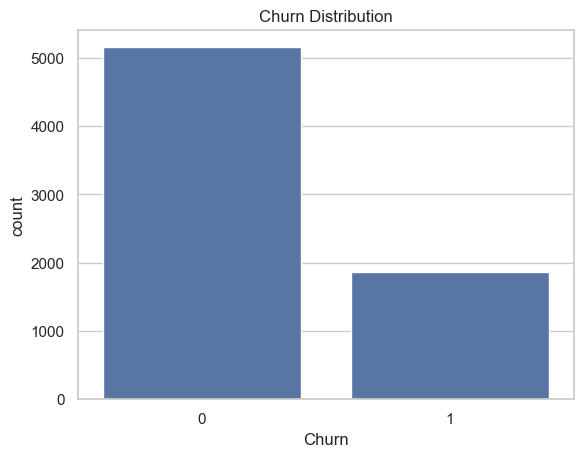

In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

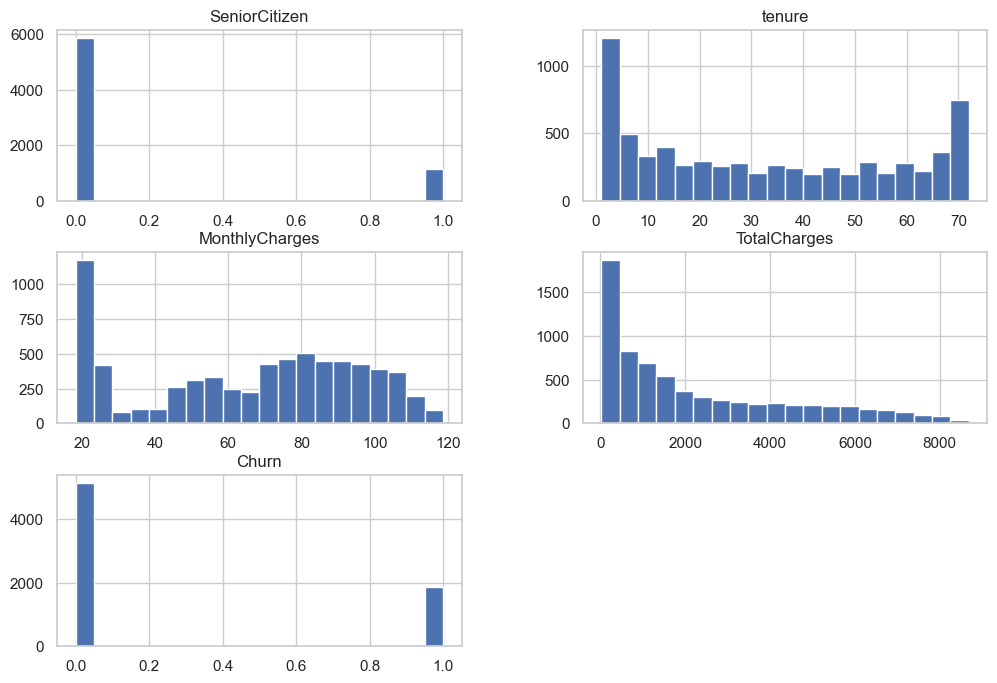

In [14]:
df.hist(bins=20, figsize=(12,8))
plt.show()

### Feature Relationships and Insights

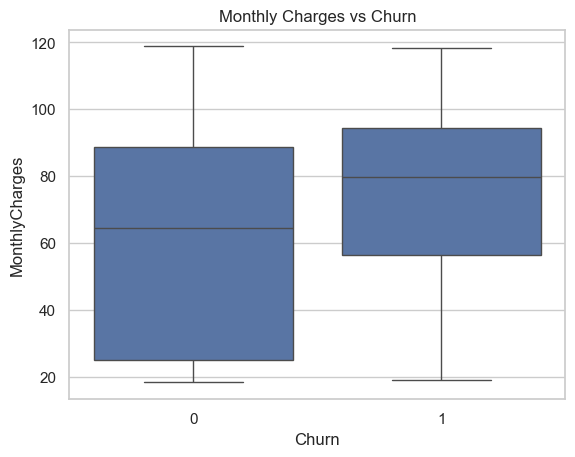

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

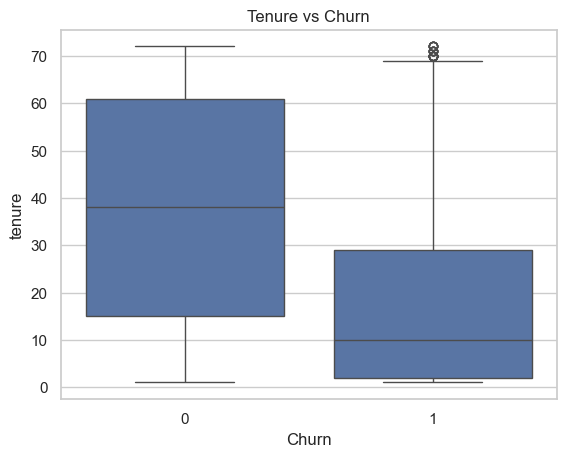

In [16]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

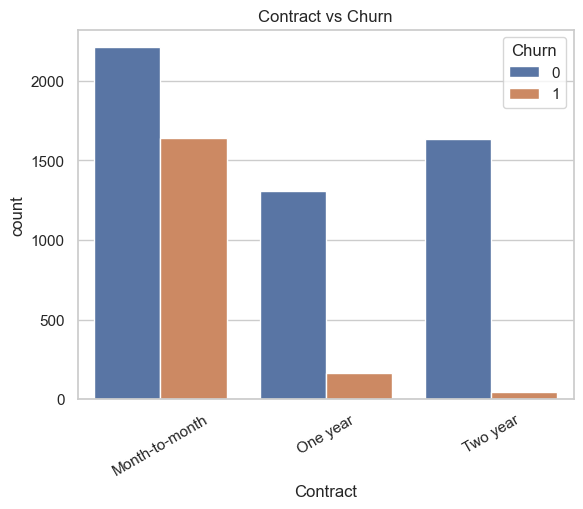

In [17]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.title("Contract vs Churn")
plt.show()

In [18]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64

In [19]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.721133,61.387415,2560.264118
1,18.088853,74.604308,1541.376548


In [20]:
df.groupby("Contract")["Churn"].mean() * 100

Contract
Month-to-month    42.642097
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64

In [21]:
df.groupby("InternetService")["Churn"].mean() * 100

InternetService
DSL            18.931234
Fiber optic    41.779935
No              7.237716
Name: Churn, dtype: float64

In [22]:
df.groupby("PaymentMethod")["Churn"].mean() * 100

PaymentMethod
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Electronic check             45.146248
Mailed check                 19.017632
Name: Churn, dtype: float64

In [23]:
df.groupby("TechSupport")["Churn"].mean() * 100

TechSupport
No                     41.512702
No internet service     7.237716
Yes                    15.196078
Name: Churn, dtype: float64

In [24]:
# Churn rate %
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    73.509272
1    26.490728
Name: proportion, dtype: float64


In [25]:
# Group churn rate
contract_churn = df.groupby("Contract")["Churn"].mean() * 100
print(contract_churn)

Contract
Month-to-month    42.642097
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


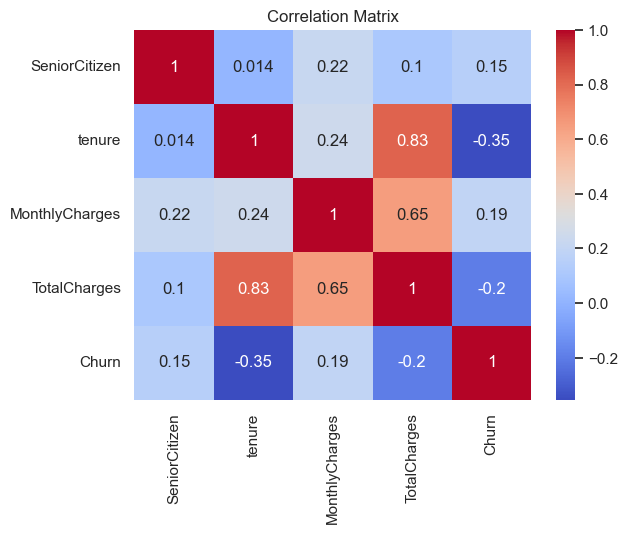

In [26]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

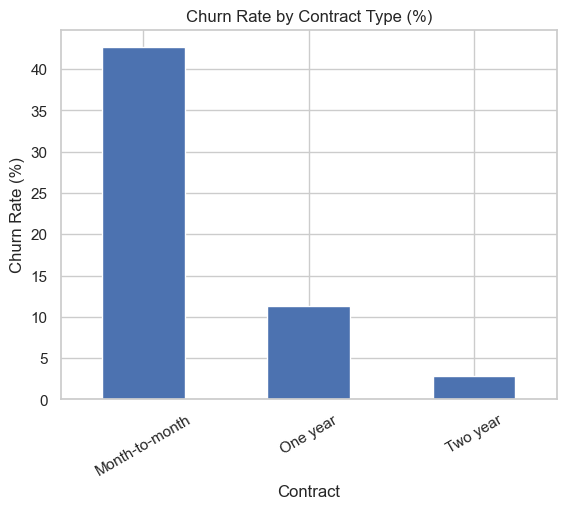

In [27]:
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

## Feature Importance Analysis

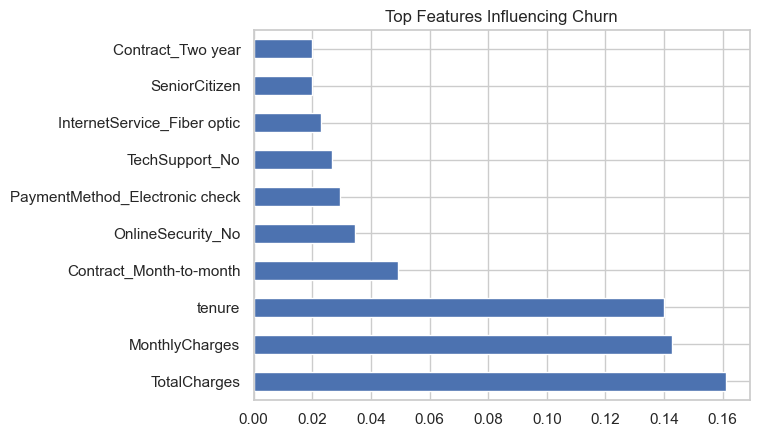

In [28]:
from sklearn.ensemble import RandomForestClassifier

X = pd.get_dummies(df.drop("Churn", axis=1))
y = df["Churn"]

model = RandomForestClassifier()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind="barh")
plt.title("Top Features Influencing Churn")
plt.show()

In [29]:
df.to_csv("clean_dataset.csv", index=False)

## Key Insights

### 1. Overall Churn Rate
Approximately **26.58% of customers have churned**, while **73.42% have remained**, indicating that although most customers stay, a significant portion still leaves the service.

---

### 2. Tenure and Customer Retention
Customers who churn have a significantly lower average tenure (**18.09 months**) compared to those who remain (**37.72 months**).  
This suggests that newer customers are far more likely to leave early, making early-stage retention critical.

---

### 3. Monthly Charges and Churn
Churned customers have a higher average monthly charge (**R74.60**) compared to retained customers (**R61.39**).  
This indicates that higher pricing may contribute to customer dissatisfaction and increased churn risk.

---

### 4. Contract Type Impact
Contract type has a strong influence on churn:
- **Month-to-month:** 42.64% churn rate  
- **One-year:** 11.28%  
- **Two-year:** 2.85%  

Customers on month-to-month contracts are significantly more likely to churn, while long-term contracts greatly improve retention.

---

### 5. Internet Service Type
Churn rates vary significantly by internet service:
- **Fiber optic:** 41.78%  
- **DSL:** 18.93%  
- **No internet service:** 7.24%  

Customers using fiber optic services show the highest churn, possibly due to higher costs or service expectations.

---

### 6. Payment Method Influence
Payment method also affects churn:
- **Electronic check:** 45.15% (highest)  
- **Bank transfer (automatic):** 16.73%  
- **Credit card (automatic):** 15.25%  
- **Mailed check:** 19.02%  

Customers using electronic checks are far more likely to churn, suggesting a link between payment behavior and retention.

---

### 7. Technical Support and Churn
Technical support availability plays a key role:
- **No tech support:** 41.51% churn  
- **With tech support:** 15.20% churn  
- **No internet service:** 7.24%  

Customers without technical support are almost three times more likely to churn, highlighting the importance of customer support services.

---

## Business Recommendations

- Encourage customers to switch to long-term contracts to improve retention  
- Provide early engagement strategies for new customers  
- Review pricing strategies for high monthly charge customers  
- Investigate issues related to fiber optic services  
- Promote automatic payment methods over electronic checks  
- Improve access to and awareness of technical support services

# Data PreProcessing

#### Loading the cleaned dataset that will be used for preprocessing

In [30]:
df = pd.read_csv('clean_dataset.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Understanding the Data

In [31]:
# Whant to see the data frame characteristics.
#  does it have missing values? Its data types, column names and the number of rows?
df.info()

# See the descriptive statistics for the numerical columns
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7010.0,0.162767,0.369180,0.00,0.0000,0.000,0.0000,1.00
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80
Churn,7010.0,0.264907,0.441315,0.00,0.0000,0.000,1.0000,1.00


In [32]:
# Check for unique values
# This helps in identifying binary, categorical and numerical columns
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [33]:
# Checking for missing values
# this will tell us how many missing values we have in each column
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Standardising Text Values (Creating Uniformity)

In [34]:
# remove extra spaces, if any
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# convert all letters to lowercase, ensuring consistency
df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,female,0,yes,no,1,no,no phone service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,0
1,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one year,no,mailed check,56.95,1889.50,0
2,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,1
3,male,0,no,no,45,no,no phone service,dsl,yes,no,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,0
4,female,0,no,no,2,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,1


# Separating Data

In [35]:
# Separating the target variable from other features
# Features
x = df.drop(['Churn'], axis = 1)

# Target variable
y = df['Churn']

display(x,y)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,female,0,yes,no,1,no,no phone service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85
1,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one year,no,mailed check,56.95,1889.50
2,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15
3,male,0,no,no,45,no,no phone service,dsl,yes,no,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75
4,female,0,no,no,2,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005,male,0,yes,yes,24,yes,yes,dsl,yes,no,yes,yes,yes,yes,one year,yes,mailed check,84.80,1990.50
7006,female,0,yes,yes,72,yes,yes,fiber optic,no,yes,yes,no,yes,yes,one year,yes,credit card (automatic),103.20,7362.90
7007,female,0,yes,yes,11,no,no phone service,dsl,yes,no,no,no,no,no,month-to-month,yes,electronic check,29.60,346.45
7008,male,1,yes,no,4,yes,yes,fiber optic,no,no,no,no,no,no,month-to-month,yes,mailed check,74.40,306.60


0       0
1       0
2       1
3       0
4       1
       ..
7005    0
7006    0
7007    0
7008    1
7009    0
Name: Churn, Length: 7010, dtype: int64

# Encoding Categorical Data

In [36]:
# Convert categorical data
x = pd.get_dummies(x, drop_first=True)

# Training Random Forest

In [37]:
# model
rf = RandomForestClassifier(n_estimators =100, max_depth = 10, random_state=42)
rf.fit(x,y)

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importance)

                                  Feature  Importance
1                                  tenure    0.196810
3                            TotalCharges    0.159327
2                          MonthlyCharges    0.126328
10            InternetService_fiber optic    0.063909
25                      Contract_two year    0.058024
28         PaymentMethod_electronic check    0.054177
13                     OnlineSecurity_yes    0.037806
24                      Contract_one year    0.033913
19                        TechSupport_yes    0.023283
26                   PaperlessBilling_yes    0.021381
16   DeviceProtection_no internet service    0.015119
0                           SeniorCitizen    0.014943
6                          Dependents_yes    0.014845
9                       MultipleLines_yes    0.014034
15                       OnlineBackup_yes    0.013849
4                             gender_male    0.013650
12     OnlineSecurity_no internet service    0.013364
5                           

# Useful Features Selection

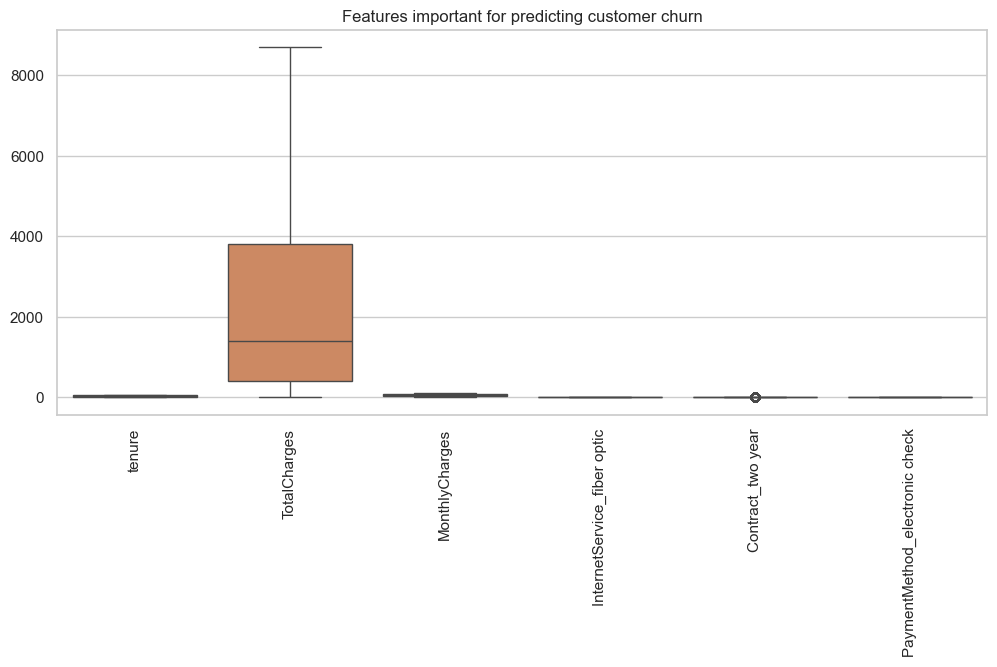

In [38]:
# Features that will help with predicting customer churn
important_features =feature_importance[feature_importance['Importance'] > 0.05]

selected_columns = important_features['Feature']
selected = x[selected_columns]

# Boxplot to identify outliers
plt.figure(figsize=(12,5))
sns.boxplot(data=selected)
plt.title(f'Features important for predicting customer churn')
plt.xticks(rotation=90)
plt.show()

In [39]:
x[selected_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7010.0,32.520399,24.520441,1.00,9.0000,29.000,56.0000,72.00
TotalCharges,7010.0,2290.353388,2266.820832,18.80,408.3125,1403.875,3807.8375,8684.80
MonthlyCharges,7010.0,64.888666,30.064769,18.25,35.7500,70.400,89.9000,118.75


# Checking for Skewness

In [40]:
skewness = selected.skew().sort_values(ascending=False)
print(skewness)

Contract_two year                 1.215443
TotalCharges                      0.958322
PaymentMethod_electronic check    0.692103
InternetService_fiber optic       0.238533
tenure                            0.233740
MonthlyCharges                   -0.225686
dtype: float64


# Data Splitting

In [41]:
# Split data into training data and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=42)

# Feature Scaling

In [42]:
scaler = StandardScaler()

# only fitting the training data
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## Fit Logistic Regression Model

In [43]:
model = LogisticRegression(random_state = 0, solver='lbfgs' )
model.fit(x_train, y_train)

y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

Training Confusion Matrix:
 [[3628  444]
 [ 668  868]]
Training Accuracy: 80.2%


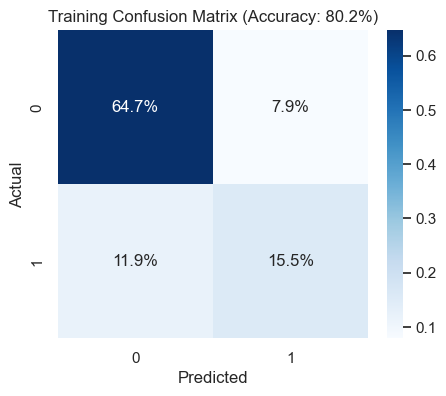

In [45]:
from sklearn.metrics import confusion_matrix, accuracy_score

cm_train = confusion_matrix(y_train, y_train_pred)
print("Training Confusion Matrix:\n", cm_train)

# To evaluate how well the data is trained 
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy * 100:.1f}%")

cm_train_prob = cm_train / np.sum(cm_train)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_train_prob, annot=True, cmap='Blues', fmt='.1%')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Training Confusion Matrix (Accuracy: {train_accuracy * 100:.1f}%)")
plt.show()


In [ ]:
# testing the accuracy of the testing data 

cm_test = confusion_matrix(y_test, y_test_pred)
print("Training Confusion Matrix:\n", cm_test)

# To evaluate how well the data is trained 
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {accuracy * 100:.1f}%")

cm_test_prob = cm_test / np.sum(cm_test)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_test_prob, annot=True, cmap='Blues', fmt='.1%')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Testing Confusion Matrix (Accuracy: {accuracy * 100:.1f}%)")
plt.show()

In [ ]:
#The test accuracy (82.2%) is slightly higher than the training accuracy (80.2%) by 2.2%, 
#which suggests that the model generalizes well to unseen data, indicating a well-performing model.


## Fit Decision Tree Model 

In [ ]:
#plotting the decision tree
# Limit the tree
dtree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"

)

dtree.fit(x_train, y_train)


plt.figure(figsize=(20,10))

plot_tree(
    dtree,
    feature_names=x.columns,
    filled=True
)

plt.show()

In [ ]:
# Predictions on training data using decision trees
train_pred = dtree.predict(x_train)
train_accuracy = accuracy_score(y_train, train_pred)

# Predictions on test data
test_pred = dtree.predict(x_test)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

In [ ]:
#The decision tree shows similar training and test accuracy, indicating good generalization and no strong overfitting. 
#However, model comparison is needed before concluding whether 
#logistic regression performs better.